In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 데이터 변환 및 로드
transform = transforms.Compose([
    transforms.ToTensor()
])

# 학습 데이터셋 (일부만 사용하여 오버피팅 유도)
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
subset_indices = torch.arange(0, 2000)  # 학습 데이터 2000개만 사용
train_subset = torch.utils.data.Subset(train_dataset, subset_indices)
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)

# 테스트 데이터셋
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [13]:
class OverfittingNet(nn.Module):
    def __init__(self):
        super(OverfittingNet, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(28*28, 512)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.layer4 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.relu3(self.layer3(x))
        x = self.layer4(x)
        return x

# 모델, 손실 함수, 옵티마이저 정의
model = OverfittingNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [14]:
# 학습 함수
def train(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for inputs, targets in loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

# 평가 함수
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    accuracy = 100 * correct / total
    return running_loss / len(loader), accuracy

Epoch [1/20] - Train Loss: 2.2996, Test Loss: 2.2985, Accuracy: 13.78%
Epoch [2/20] - Train Loss: 2.2967, Test Loss: 2.2961, Accuracy: 16.98%
Epoch [3/20] - Train Loss: 2.2940, Test Loss: 2.2935, Accuracy: 18.89%
Epoch [4/20] - Train Loss: 2.2910, Test Loss: 2.2908, Accuracy: 18.85%
Epoch [5/20] - Train Loss: 2.2880, Test Loss: 2.2880, Accuracy: 18.89%
Epoch [6/20] - Train Loss: 2.2849, Test Loss: 2.2848, Accuracy: 19.08%
Epoch [7/20] - Train Loss: 2.2822, Test Loss: 2.2815, Accuracy: 19.61%
Epoch [8/20] - Train Loss: 2.2782, Test Loss: 2.2778, Accuracy: 22.11%
Epoch [9/20] - Train Loss: 2.2734, Test Loss: 2.2737, Accuracy: 24.27%
Epoch [10/20] - Train Loss: 2.2692, Test Loss: 2.2691, Accuracy: 27.85%
Epoch [11/20] - Train Loss: 2.2647, Test Loss: 2.2640, Accuracy: 31.84%
Epoch [12/20] - Train Loss: 2.2584, Test Loss: 2.2581, Accuracy: 34.82%
Epoch [13/20] - Train Loss: 2.2520, Test Loss: 2.2514, Accuracy: 37.88%
Epoch [14/20] - Train Loss: 2.2447, Test Loss: 2.2437, Accuracy: 41.39%
E

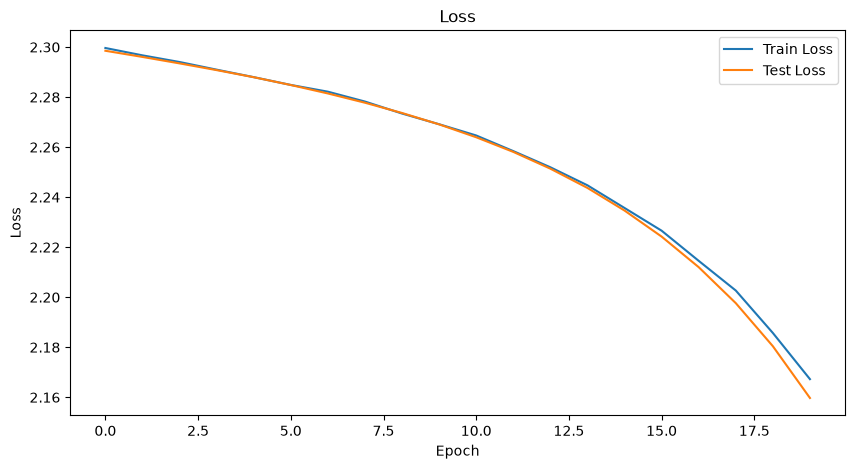

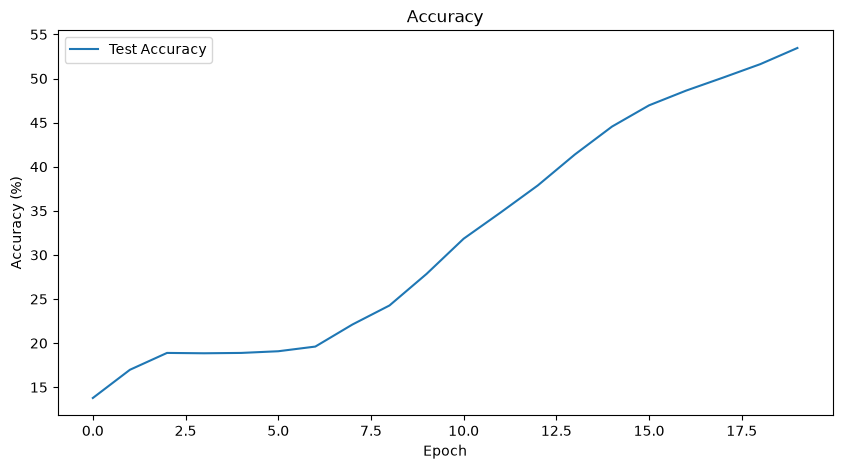

In [15]:
# 학습 및 평가 기록을 저장할 리스트
train_losses = []
test_losses = []
test_accuracies = []

num_epochs = 20
for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.2f}%')

# 손실 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Loss')
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 정확도 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

In [16]:
# 데이터 변환에 데이터 증강 기법 추가
transform_augmented = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

# 데이터셋 및 로더 재정의
train_dataset_augmented = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_augmented)
train_subset_augmented = torch.utils.data.Subset(train_dataset_augmented, subset_indices)
train_loader_augmented = torch.utils.data.DataLoader(train_subset_augmented, batch_size=64, shuffle=True)

In [17]:
class ImprovedNet(nn.Module):
    def __init__(self):
        super(ImprovedNet, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(28*28, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.layer2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.layer3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()
        self.layer4 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout1(self.relu1(self.bn1(self.layer1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer2(x))))
        x = self.relu3(self.bn3(self.layer3(x)))
        x = self.layer4(x)
        return x

# 모델, 손실 함수, 옵티마이저 재정의 (L2 정규화 적용)
model_improved = ImprovedNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_improved.parameters(), lr=0.01, weight_decay=0.001)

Epoch [1/20] - Train Loss: 2.2465, Test Loss: 2.1564, Accuracy: 35.38%
Epoch [2/20] - Train Loss: 1.9984, Test Loss: 1.8078, Accuracy: 64.51%
Epoch [3/20] - Train Loss: 1.7760, Test Loss: 1.5824, Accuracy: 69.30%
Epoch [4/20] - Train Loss: 1.5852, Test Loss: 1.3930, Accuracy: 72.07%
Epoch [5/20] - Train Loss: 1.4203, Test Loss: 1.2299, Accuracy: 75.66%
Epoch [6/20] - Train Loss: 1.2901, Test Loss: 1.0965, Accuracy: 77.75%
Epoch [7/20] - Train Loss: 1.1698, Test Loss: 0.9765, Accuracy: 80.44%
Epoch [8/20] - Train Loss: 1.0686, Test Loss: 0.8900, Accuracy: 81.55%
Epoch [9/20] - Train Loss: 0.9920, Test Loss: 0.8026, Accuracy: 82.95%
Epoch [10/20] - Train Loss: 0.9082, Test Loss: 0.7545, Accuracy: 83.80%
Epoch [11/20] - Train Loss: 0.8472, Test Loss: 0.6647, Accuracy: 85.45%
Epoch [12/20] - Train Loss: 0.7780, Test Loss: 0.6232, Accuracy: 86.11%
Epoch [13/20] - Train Loss: 0.7376, Test Loss: 0.5845, Accuracy: 86.90%
Epoch [14/20] - Train Loss: 0.6952, Test Loss: 0.5387, Accuracy: 87.10%
E

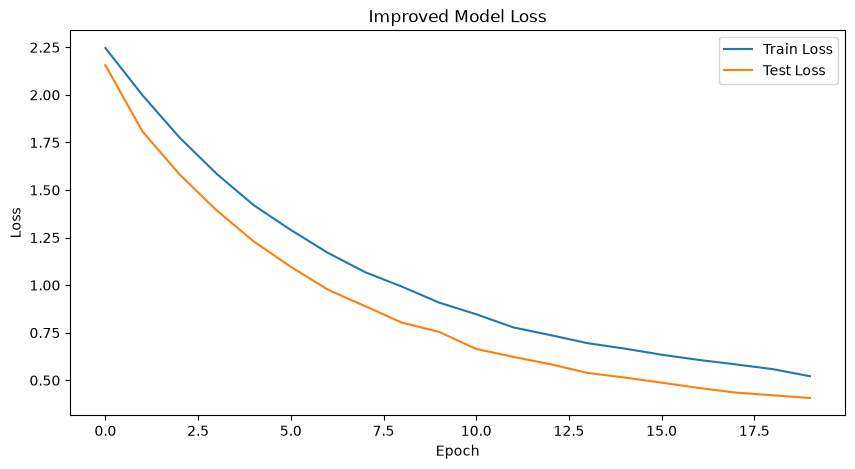

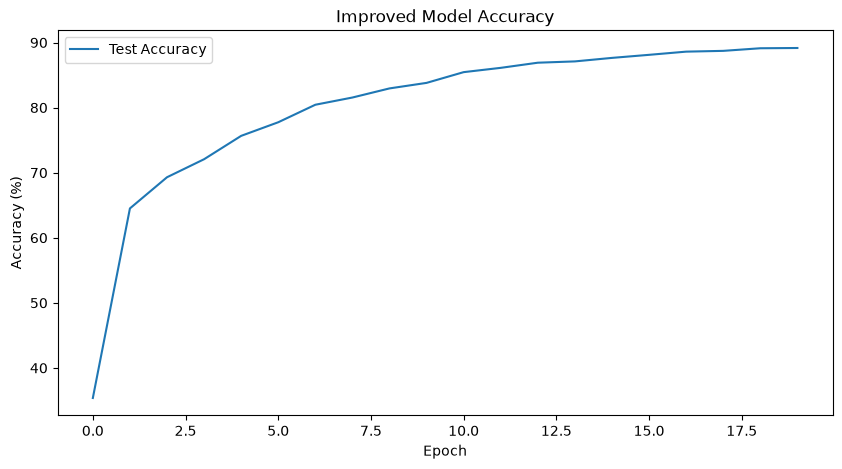

In [18]:
train_losses_improved = []
test_losses_improved = []
test_accuracies_improved = []

best_loss = float('inf')
patience = 3
trigger_times = 0

num_epochs = 20
for epoch in range(num_epochs):
    train_loss = train(model_improved, train_loader_augmented, optimizer, criterion)
    test_loss, test_accuracy = evaluate(model_improved, test_loader, criterion)

    train_losses_improved.append(train_loss)
    test_losses_improved.append(test_loss)
    test_accuracies_improved.append(test_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.2f}%')

    # 조기 종료 조건 확인
    if test_loss < best_loss:
        best_loss = test_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f'Early stopping counter: {trigger_times}/{patience}')
        if trigger_times >= patience:
            print('Early stopping!')
            break

# 손실 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Improved Model Loss')
plt.plot(train_losses_improved, label='Train Loss')
plt.plot(test_losses_improved, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 정확도 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Improved Model Accuracy')
plt.plot(test_accuracies_improved, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 시드 설정
torch.manual_seed(0)

# 데이터셋 생성: Sine 함수
X = np.linspace(-10, 10, 200)
y = np.sin(X) + 0.1 * np.random.randn(200)  # 약간의 노이즈 추가

# 훈련 데이터와 테스트 데이터로 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 파이토치 텐서로 변환
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [3]:
class OverfittingModel(nn.Module):
    def __init__(self):
        super(OverfittingModel, self).__init__()
        # 아주 많은 은닉층을 추가하여 복잡한 모델을 만듭니다.
        self.fc1 = nn.Linear(1, 50)
        self.fc2 = nn.Linear(50, 200)
        self.fc3 = nn.Linear(200, 500)
        self.fc4 = nn.Linear(500, 200)
        self.fc5 = nn.Linear(200, 50)
        self.fc6 = nn.Linear(50, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        return x

# 모델 초기화
model = OverfittingModel()

In [4]:
# 손실 함수와 옵티마이저 설정
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 훈련 과정
num_epochs = 500
train_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # 순전파
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # 역전파
    loss.backward()
    optimizer.step()

    # 손실 기록
    train_losses.append(loss.item())

    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# 훈련 후 모델 평가
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

Epoch [50/500], Loss: 0.1808
Epoch [100/500], Loss: 0.1055
Epoch [150/500], Loss: 0.0336
Epoch [200/500], Loss: 0.0149
Epoch [250/500], Loss: 0.0087
Epoch [300/500], Loss: 0.0083
Epoch [350/500], Loss: 0.0080
Epoch [400/500], Loss: 0.0083
Epoch [450/500], Loss: 0.0075
Epoch [500/500], Loss: 0.0074


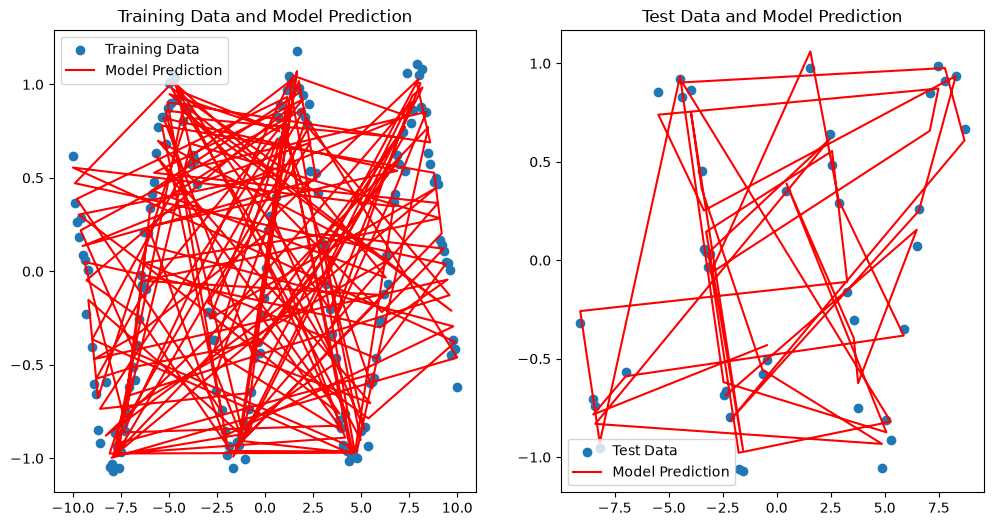

In [5]:
# 훈련 데이터와 테스트 데이터에 대한 예측 시각화
plt.figure(figsize=(12, 6))

# 훈련 데이터와 예측
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, label="Training Data")
plt.plot(X_train, train_preds.numpy(), label="Model Prediction", color='r')
plt.title('Training Data and Model Prediction')
plt.legend()

# 테스트 데이터와 예측
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, label="Test Data")
plt.plot(X_test, test_preds.numpy(), label="Model Prediction", color='r')
plt.title('Test Data and Model Prediction')
plt.legend()

plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 시드 설정
torch.manual_seed(0)

# 데이터셋 생성: 다항식 함수 y = x^3 + 노이즈
X = np.linspace(-5, 5, 1000)
y = X**3 + 0.5 * np.random.randn(1000)  # 약간의 노이즈 추가

# 훈련 데이터와 테스트 데이터로 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 파이토치 텐서로 변환
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [7]:
class SimpleLinearModel(nn.Module):
    def __init__(self):
        super(SimpleLinearModel, self).__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

In [8]:
class PolynomialModel(nn.Module):
    def __init__(self, degree=3):
        super(PolynomialModel, self).__init__()
        self.poly = nn.Sequential(
            nn.Linear(1, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 1)
        )

    def forward(self, x):
        return self.poly(x)

In [9]:
# 훈련 함수
def train_model(model, X_train_tensor, y_train_tensor, num_epochs=1000, learning_rate=0.01):
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # 훈련 과정
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        loss.backward()
        optimizer.step()

    return model

# 1. 단순 선형 회귀 모델 훈련
linear_model = SimpleLinearModel()
linear_model = train_model(linear_model, X_train_tensor, y_train_tensor)

# 2. 다항식 회귀 모델 훈련
poly_model = PolynomialModel(degree=3)
poly_model = train_model(poly_model, X_train_tensor, y_train_tensor)

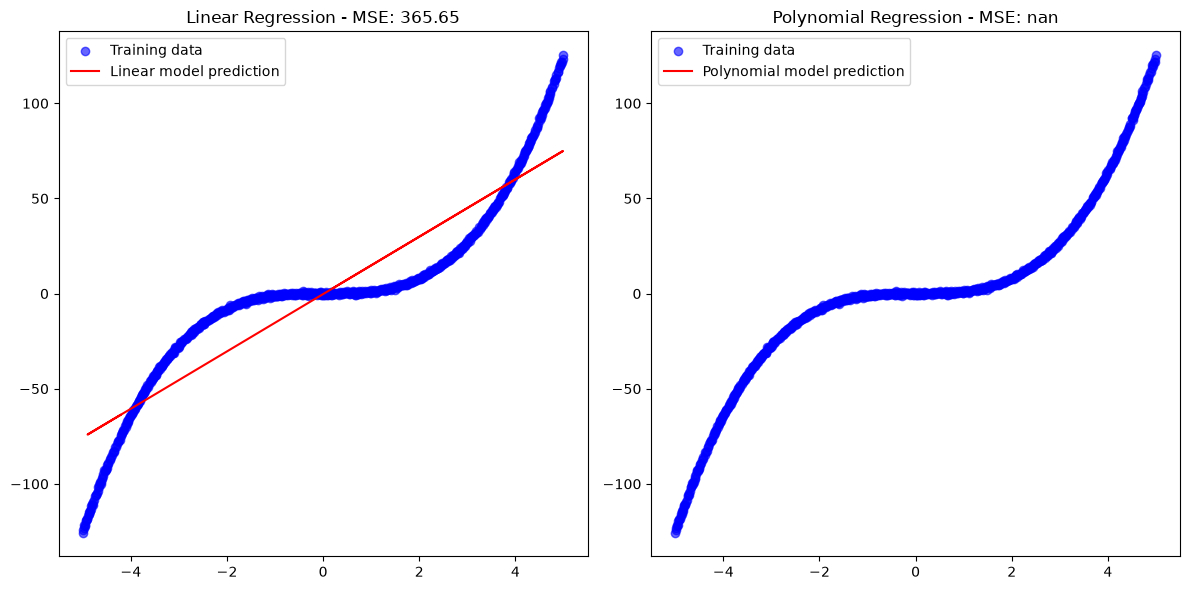

In [10]:
# 모델 평가 함수
def evaluate_model(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor)
        mse = nn.MSELoss()(predictions, y_tensor)
    return predictions, mse.item()

# 1. 선형 회귀 모델 평가
linear_predictions, linear_mse = evaluate_model(linear_model, X_test_tensor, y_test_tensor)

# 2. 다항식 회귀 모델 평가
poly_predictions, poly_mse = evaluate_model(poly_model, X_test_tensor, y_test_tensor)

# 시각화
plt.figure(figsize=(12, 6))

# 훈련 데이터 및 예측 결과 시각화
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, label="Training data", color="blue", alpha=0.6)
plt.plot(X_test, linear_predictions, label="Linear model prediction", color="red")
plt.title(f"Linear Regression - MSE: {linear_mse:.2f}")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, label="Training data", color="blue", alpha=0.6)
plt.plot(X_test, poly_predictions, label="Polynomial model prediction", color="red")
plt.title(f"Polynomial Regression - MSE: {poly_mse:.2f}")
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score

# 성별 구별을 위한 데이터 생성
np.random.seed(42)

# 1000명의 데이터를 생성: 나이, 키, 체중 특성
# 나이: 18~60, 키: 150~190 cm, 체중: 40~100 kg
X = np.random.rand(1000, 3).astype(np.float32)
X[:, 0] = X[:, 0] * 43 + 18  # 나이: 18~60
X[:, 1] = X[:, 1] * 40 + 150  # 키: 150~190
X[:, 2] = X[:, 2] * 60 + 40  # 체중: 40~100

# 성별 (0: 여자, 1: 남자) 라벨 생성
y = (X[:, 0] > 30).astype(np.float32)  # 30세 이상이면 남자, 아니면 여자

# 데이터셋 나누기 (훈련과 테스트)
train_size = int(0.8 * len(X))  # 80% 훈련 데이터
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# DataLoader 설정
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 모델 정의
class GenderNN(nn.Module):
    def __init__(self):
        super(GenderNN, self).__init__()
        self.fc1 = nn.Linear(3, 64)  # 3개의 입력 특성 (나이, 키, 체중)
        self.dropout = nn.Dropout(0.5)  # 드롭아웃 적용
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)  # 이진 분류 (여자: 0, 남자: 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 첫 번째 은닉층
        x = self.dropout(x)  # 드롭아웃 적용
        x = torch.relu(self.fc2(x))  # 두 번째 은닉층
        x = torch.sigmoid(self.fc3(x))  # 출력층
        return x

# 모델 인스턴스
model = GenderNN()

# 손실 함수와 옵티마이저 설정
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)

# 훈련 함수
def train(model, train_loader, criterion, optimizer, epochs=10):
    model.train()  # 훈련 모드로 설정
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()  # 기울기 초기화

            # 순전파
            outputs = model(inputs)

            # 손실 계산
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()  # 역전파
            optimizer.step()  # 가중치 업데이트

            running_loss += loss.item()

        # 에포크마다 손실 출력
        print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader)}')

# 훈련 시작
train(model, train_loader, criterion, optimizer, epochs=10)

# 테스트 함수
def test(model, test_loader):
    model.eval()  # 평가 모드로 설정
    all_preds = []
    all_labels = []
    with torch.no_grad():  # 기울기 계산을 하지 않음
        for inputs, labels in test_loader:
            outputs = model(inputs)
            preds = (outputs.squeeze() > 0.5).float() # 0.5를 기준으로 이진 예측
            all_preds.append(preds)
            all_labels.append(labels)

    # 결과를 텐서에서 numpy로 변환
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # 정확도 계산
    accuracy = accuracy_score(all_labels, all_preds)
    print(f'Accuracy on test data: {accuracy * 100:.2f}%')

# 테스트 시작
test(model, test_loader)

Epoch 1/10, Loss: 7.418833365807166
Epoch 2/10, Loss: 8.335851339193491
Epoch 3/10, Loss: 2.2786800265312195
Epoch 4/10, Loss: 1.5326025027495165
Epoch 5/10, Loss: 1.2631784631655767
Epoch 6/10, Loss: 1.0963627787736745
Epoch 7/10, Loss: 0.8521421322455773
Epoch 8/10, Loss: 0.7490790990682749
Epoch 9/10, Loss: 0.6226900472090795
Epoch 10/10, Loss: 0.6735065350165734
Accuracy on test data: 87.50%
